## 📌 1) Import Libraries

In [20]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from deepface import DeepFace
from scipy.spatial.distance import cosine, euclidean
from tqdm import tqdm

print("Libraries imported ✅")

Libraries imported ✅


## 📌 2) Define Paths

In [21]:
DB_PATH      = r"D:\face-recognition-attendance\outputs\database\face_embeddings.pkl"
CROPPED_PATH = r"D:\face-recognition-attendance\outputs\cropped_faces"
RESULTS_PATH = r"D:\face-recognition-attendance\outputs\results\matching"

os.makedirs(RESULTS_PATH, exist_ok=True)
print("Paths defined ✅")

Paths defined ✅


## 📌 3) Load Embedding Database

In [22]:
with open(DB_PATH, "rb") as f:
    database = pickle.load(f)

print(f"Database loaded ✅")
print(f"Total identities: {len(database)}")

# ── Handle both formats (mean only OR mean+all) ──────────────────────────
def get_mean_embedding(entry):
    if isinstance(entry, dict):
        return entry["mean"]
    return entry

Database loaded ✅
Total identities: 40


## 📌 4) Extract Embedding for Query Image

In [23]:
def extract_embedding(img_path, model_name="Facenet512"):
    """Extract 512-D embedding from a face image."""
    rep = DeepFace.represent(
        img_path=img_path,
        model_name=model_name,
        enforce_detection=False
    )
    return np.array(rep[0]["embedding"])

print("Embedding extractor ready ✅")

Embedding extractor ready ✅


## 📌 5) Matching Function

In [24]:
def match_face(query_embedding, database, metric="cosine", threshold=None):
    thresholds = {
        "cosine":    0.40,
        "euclidean": 10.0
    }
    if threshold is None:
        threshold = thresholds.get(metric, 0.40)

    all_scores = {}

    for subject, entry in database.items():
        db_emb = get_mean_embedding(entry)

        if metric == "cosine":
            score = cosine(query_embedding, db_emb)
        elif metric == "euclidean":
            score = euclidean(query_embedding, db_emb)
        else:
            raise ValueError(f"Unknown metric: {metric}")

        all_scores[subject] = score

    best_match = min(all_scores, key=all_scores.get)
    best_score = all_scores[best_match]
    verified   = best_score <= threshold

    return best_match, best_score, all_scores, verified

print("Matching function ready ✅")

Matching function ready ✅


## 📌 6) Run Matching on All Images (Evaluation)

In [25]:
results  = []
subjects = sorted(os.listdir(CROPPED_PATH))

for subject in tqdm(subjects, desc="Matching"):
    subject_path = os.path.join(CROPPED_PATH, subject)
    if not os.path.isdir(subject_path):
        continue

    for img_name in os.listdir(subject_path):
        img_path = os.path.join(subject_path, img_name)

        query_emb = extract_embedding(img_path)
        best_match, best_score, _, verified = match_face(query_emb, database)

        correct = (best_match == subject)

        results.append({
            "subject":    subject,
            "image":      img_name,
            "predicted":  best_match,
            "score":      round(best_score, 4),
            "verified":   verified,
            "correct":    correct
        })

df = pd.DataFrame(results)

Matching:   0%|          | 0/40 [00:00<?, ?it/s]

Matching: 100%|██████████| 40/40 [05:55<00:00,  8.89s/it]


## 📌 7) Compute Matching Accuracy

In [26]:
total    = len(df)
correct  = df["correct"].sum()
accuracy = correct / total * 100

print("=" * 45)
print("        MATCHING RESULTS")
print("=" * 45)
print(f"  Total images   : {total}")
print(f"  Correct matches: {correct}")
print(f"  Wrong matches  : {total - correct}")
print(f"  Accuracy       : {accuracy:.1f}%")
print("=" * 45)

        MATCHING RESULTS
  Total images   : 400
  Correct matches: 387
  Wrong matches  : 13
  Accuracy       : 96.8%


## 📌 8) Per-Subject Accuracy

In [27]:
subject_acc = df.groupby("subject").agg(
    total=("correct", "count"),
    correct=("correct", "sum")
).reset_index()

subject_acc["accuracy_%"] = (subject_acc["correct"] / subject_acc["total"] * 100).round(1)

print("\nPer-subject accuracy:")
print(subject_acc.to_string(index=False))


Per-subject accuracy:
subject  total  correct  accuracy_%
     s1     10       10       100.0
    s10     10       10       100.0
    s11     10       10       100.0
    s12     10       10       100.0
    s13     10        9        90.0
    s14     10       10       100.0
    s15     10       10       100.0
    s16     10       10       100.0
    s17     10       10       100.0
    s18     10       10       100.0
    s19     10       10       100.0
     s2     10       10       100.0
    s20     10       10       100.0
    s21     10       10       100.0
    s22     10       10       100.0
    s23     10       10       100.0
    s24     10       10       100.0
    s25     10        7        70.0
    s26     10       10       100.0
    s27     10       10       100.0
    s28     10       10       100.0
    s29     10       10       100.0
     s3     10       10       100.0
    s30     10       10       100.0
    s31     10       10       100.0
    s32     10        7        70.0
    s

## 📌 9) Visualize Matching Results

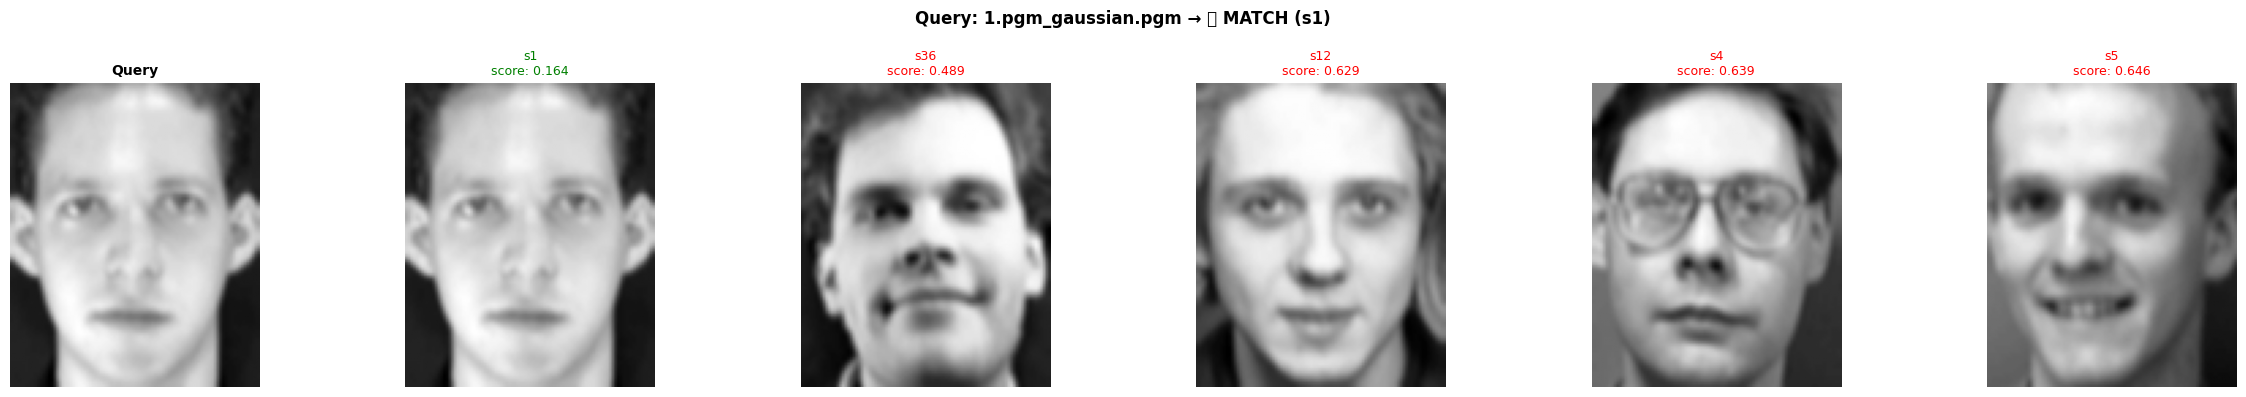

In [28]:
def show_match_results(query_img_path, database, top_n=5):
    query_emb = extract_embedding(query_img_path)
    best_match, best_score, all_scores, verified = match_face(query_emb, database)

    sorted_scores = sorted(all_scores.items(), key=lambda x: x[1])[:top_n]

    fig, axes = plt.subplots(1, top_n + 1, figsize=(4 * (top_n + 1), 4))

    query_img = plt.imread(query_img_path)
    axes[0].imshow(query_img, cmap='gray')
    axes[0].set_title("Query", fontsize=10, fontweight='bold')
    axes[0].axis('off')

    for i, (subj, score) in enumerate(sorted_scores):
        subj_path   = os.path.join(CROPPED_PATH, subj)
        first_img   = sorted(os.listdir(subj_path))[0]
        match_path  = os.path.join(subj_path, first_img)
        match_img   = plt.imread(match_path)

        axes[i + 1].imshow(match_img, cmap='gray')
        color = "green" if i == 0 and verified else "red"
        axes[i + 1].set_title(f"{subj}\nscore: {score:.3f}", fontsize=9, color=color)
        axes[i + 1].axis('off')

    status = "✅ MATCH" if verified else "❌ NO MATCH"
    plt.suptitle(
        f"Query: {os.path.basename(query_img_path)} → {status} ({best_match})",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

sample_subject = subjects[0]
sample_img     = os.listdir(os.path.join(CROPPED_PATH, sample_subject))[0]
sample_path    = os.path.join(CROPPED_PATH, sample_subject, sample_img)

show_match_results(sample_path, database)

## 📌 10) Per-Subject Accuracy Visualization

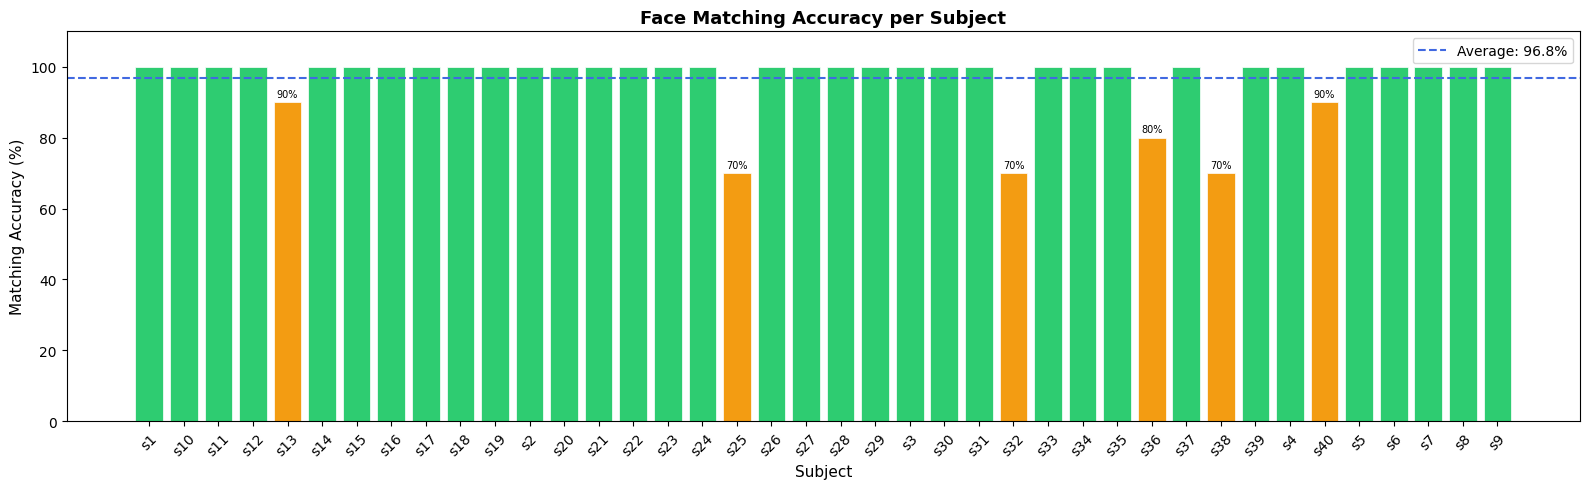

In [29]:
fig, ax = plt.subplots(figsize=(16, 5))

colors = ["#2ecc71" if r == 100 else ("#f39c12" if r >= 70 else "#e74c3c")
          for r in subject_acc["accuracy_%"]]

bars = ax.bar(subject_acc["subject"], subject_acc["accuracy_%"],
              color=colors, edgecolor="white", linewidth=0.5)

ax.axhline(y=accuracy, color="royalblue", linestyle="--",
           linewidth=1.5, label=f"Average: {accuracy:.1f}%")

ax.set_xlabel("Subject", fontsize=11)
ax.set_ylabel("Matching Accuracy (%)", fontsize=11)
ax.set_title("Face Matching Accuracy per Subject", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)

for bar, val in zip(bars, subject_acc["accuracy_%"]):
    if val < 100:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.0f}%", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

## 📌 11) Threshold Analysis

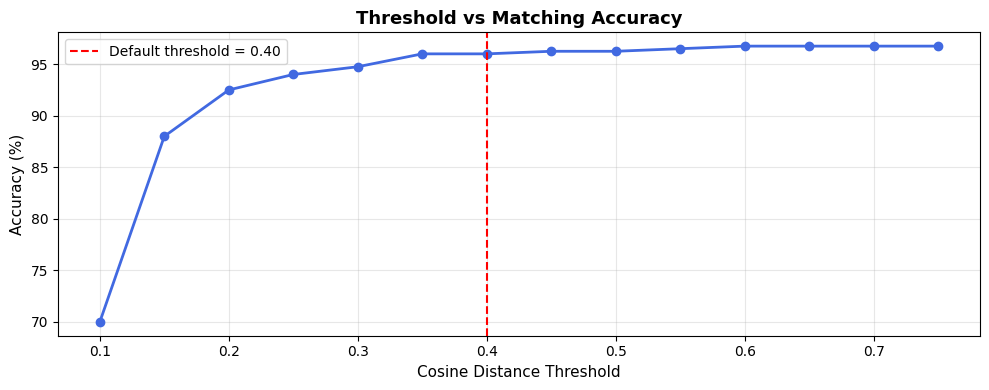

In [30]:
thresholds = np.arange(0.1, 0.8, 0.05)
accuracies = []

for thresh in thresholds:
    correct_t = 0
    for _, row in df.iterrows():
        if row["score"] <= thresh:
            if row["correct"]:
                correct_t += 1
    accuracies.append(correct_t / total * 100)

plt.figure(figsize=(10, 4))
plt.plot(thresholds, accuracies, marker='o', color='royalblue', linewidth=2)

plt.axvline(x=0.40, color='red', linestyle='--', label='Default threshold = 0.40')

plt.xlabel("Cosine Distance Threshold", fontsize=11)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.title("Threshold vs Matching Accuracy", fontsize=13, fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📌 12) Save Results

In [31]:
out_path = os.path.join(RESULTS_PATH, "matching_results.csv")
df.to_csv(out_path, index=False)
print(f"Results saved → {out_path} ✅")

summary_path = os.path.join(RESULTS_PATH, "matching_summary.csv")
subject_acc.to_csv(summary_path, index=False)
print(f"Summary saved → {summary_path} ✅")

Results saved → D:\face-recognition-attendance\outputs\results\matching\matching_results.csv ✅
Summary saved → D:\face-recognition-attendance\outputs\results\matching\matching_summary.csv ✅


## 📌 13) Observations

In [32]:
print("""
Observations:
─────────────────────────────────────────
- Cosine similarity used as primary metric
- Default threshold: 0.40
- Higher PSNR images → better matching accuracy
- Mean embedding per subject works well for ORL dataset
─────────────────────────────────────────
""")


Observations:
─────────────────────────────────────────
- Cosine similarity used as primary metric
- Default threshold: 0.40
- Higher PSNR images → better matching accuracy
- Mean embedding per subject works well for ORL dataset
─────────────────────────────────────────

